In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os,sys
import json

import pickle
import matplotlib.cm as cm
from matplotlib.colors import LogNorm
from matplotlib.ticker import MultipleLocator

from scipy.optimize import curve_fit

from scipy.interpolate import interp1d

DATA_DIR = '../data/'

plt.style.use('../paper.mplstyle')

# Try to fit the relevant parameters

In [4]:
data_path = '../data/parameter_matches.json'

with open(data_path, 'r') as f:
     param_pairs_dict = json.load(f)

# Convert keys to float
param_pairs_dict = {float(k): v for k, v in param_pairs_dict.items()}

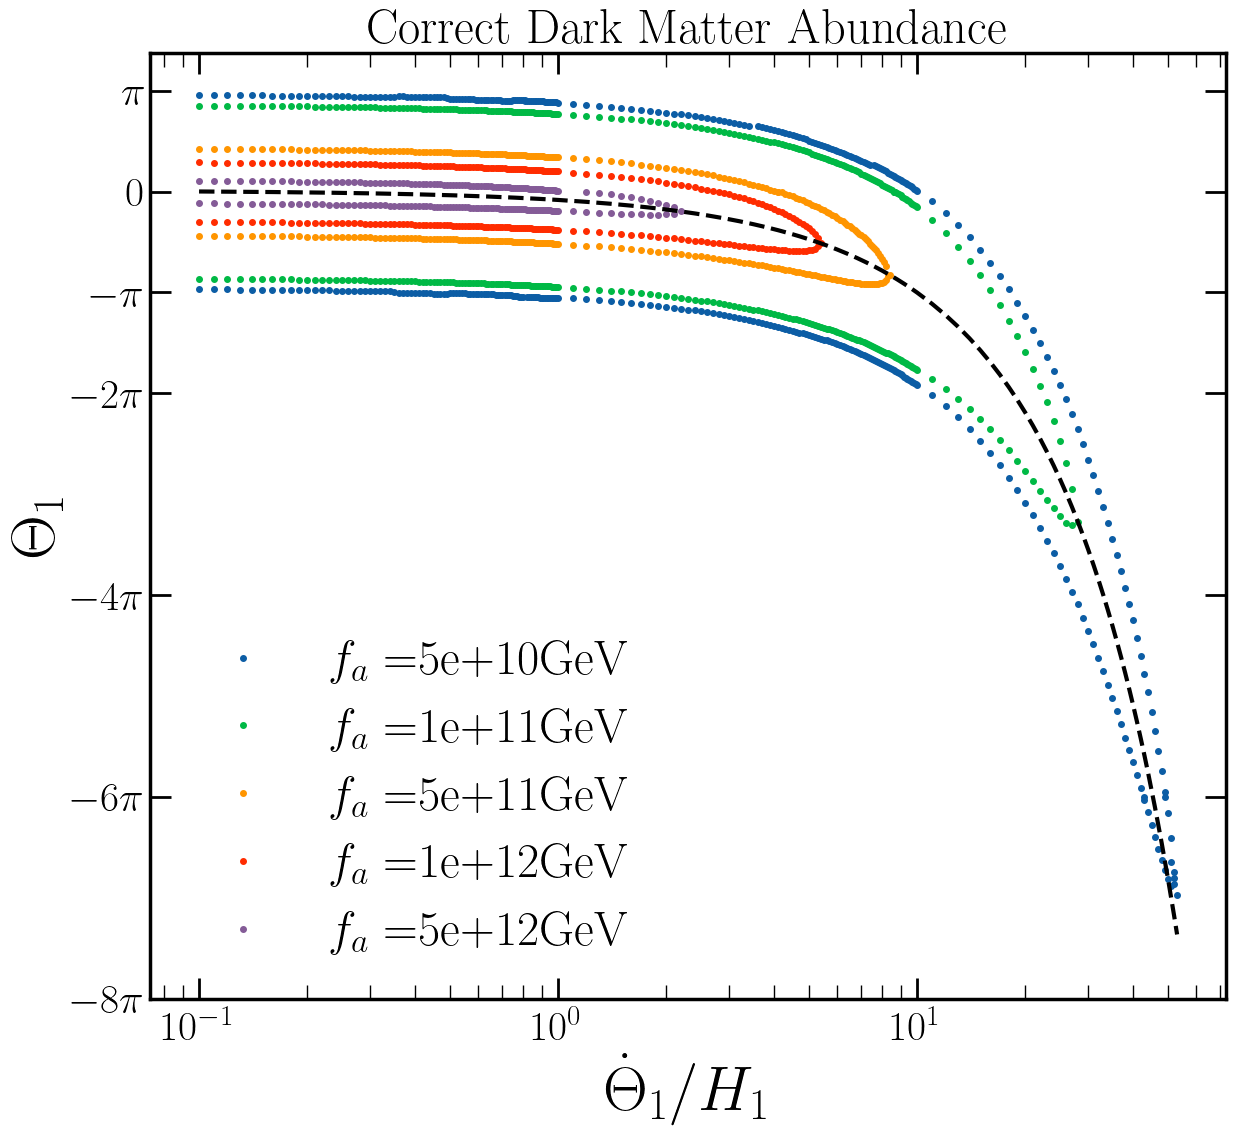

In [23]:
fit_theta1_vals = []
fit_vheta1_vals = []


curves_vheta = []
curves_theta = []

for k, v in param_pairs_dict.items():
    if k > 10**11:
        theta1_vals = np.asarray([t[0] for t in v])
        vheta1_vals = np.asarray([t[1] for t in v])

        # Sort by x for cleaner plotting
        sort_idx = np.argsort(vheta1_vals)
        theta1_vals = theta1_vals[sort_idx]
        vheta1_vals = vheta1_vals[sort_idx]

        # Find median theta to separate branches
        median_theta = 0.5*(theta1_vals.max() + theta1_vals.min())
        upper_mask = theta1_vals > median_theta
        
        curves_vheta.append(np.concatenate([vheta1_vals[~upper_mask], vheta1_vals[upper_mask]]))
        
        curves_theta.append(np.concatenate([theta1_vals[~upper_mask], theta1_vals[upper_mask] -2*np.pi]))

        
        # Plot lower branch
        plt.plot(vheta1_vals[~upper_mask], theta1_vals[~upper_mask], markersize = 8, 
                 marker = '.', linestyle = '', label = fr'$f_a = ${k:.0e}GeV')

        # Plot shifted upper branch
        plt.plot(vheta1_vals[upper_mask], theta1_vals[upper_mask] - 2*np.pi, markersize = 8, 
                 marker = '.', linestyle = '', color = plt.gca().lines[-1].get_color())
        
        fit_theta1_vals.append(theta1_vals[-1])
        fit_vheta1_vals.append(vheta1_vals[-1])
        
    if k == 10**11:
        theta1_vals = np.asarray([t[0] for t in v])
        vheta1_vals = np.asarray([t[1] for t in v])
        
        neg_shift_idx = np.unique(np.concatenate([
            np.arange(369, 388, 2),
            np.arange(388, 399, 1),
        ]))

        pos_shift_idx = np.unique(np.concatenate([
            np.arange(0, 333, 2),
            [335]
        ]))

        # Apply shifts
        theta1_vals[neg_shift_idx] -= 2*np.pi
        theta1_vals[pos_shift_idx] += 2*np.pi
        
        curves_vheta.append(vheta1_vals)
        curves_theta.append(theta1_vals-2*np.pi)
        
        plt.plot(vheta1_vals, theta1_vals-2*np.pi, label = fr'$f_a = ${k:.0e}GeV', markersize = 8, marker = '.', linestyle = '')
        
    if k == 5*10**10:
        theta1_vals = np.asarray([t[0] for t in v])
        vheta1_vals = np.asarray([t[1] for t in v])
        
        test = vheta1_vals
        
        neg_shift_idx = np.unique(np.array([
            361, 363, 365, 367, 369, 371, 373, 375, 377, 379, 381, 383, 385, 387, 389, 
            390, 391, 392, 393, 394, 
            396, 398, 400, 402, 404, 406, 408, 410, 412, 414
            
        ]))

        dneg_shift_idx = np.unique(np.array([
            395, 397, 399, 401, 403, 405, 407, 409, 411, 413, 415, 416, 417, 418, 419, 420,
            421, 422, 423, 424, 425,
            427, 429, 431, 433, 435, 437
        ]))

        ddneg_shift_idx = np.unique(np.array([
            426, 428, 430, 432, 434, 436, 438,
            439, 440, 441, 442, 443, 444, 445, 446, 447, 448
        ]))
        
        pos_shift_idx = np.unique(np.concatenate([
            np.arange(0, 143, 2),
            np.arange(143, 145, 2),
            np.arange(144, 230, 2),
            np.arange(231, 308, 2),
            np.arange(310, 360, 2),
        ]))
        
        theta1_vals[neg_shift_idx] -= 2*np.pi
        theta1_vals[dneg_shift_idx] -= 4*np.pi
        theta1_vals[ddneg_shift_idx] -= 6*np.pi
        theta1_vals[pos_shift_idx] += 2*np.pi

        curves_vheta.append(vheta1_vals)
        curves_theta.append(theta1_vals-2*np.pi)
        
        plt.plot(vheta1_vals, theta1_vals-2*np.pi, label = fr'$f_a = ${k:.0e}GeV', markersize = 8, marker = '.', linestyle = '')
    
coeffs = np.polyfit(fit_vheta1_vals, fit_theta1_vals, deg = 2)

# Turn into a polynomial function
p = np.poly1d(coeffs)

plt.plot(test, p(test)-2*np.pi, 'k--')

plt.xlabel(r'$\dot{\Theta}_1/H_1$')
plt.ylabel(r'$\Theta_1$')
plt.xscale('log')
plt.yticks([-8*np.pi, -6*np.pi, -4*np.pi, -2*np.pi, -np.pi, 0, np.pi],
           [r'$-8\pi$', r'$-6\pi$', r'$-4\pi$', r'$-2\pi$', r'$-\pi$', r'$0$', r'$\pi$'])
plt.title('Correct Dark Matter Abundance', fontweight = 'bold')
plt.tight_layout()
plt.legend(loc = 'lower left')
plt.show()
plt.close()

In [25]:
np.save(DATA_DIR + "param_matches_theta.npy", np.array(curves_theta, dtype='object'))    
np.save(DATA_DIR + "param_matches_vheta.npy", np.array(curves_vheta, dtype='object'))   

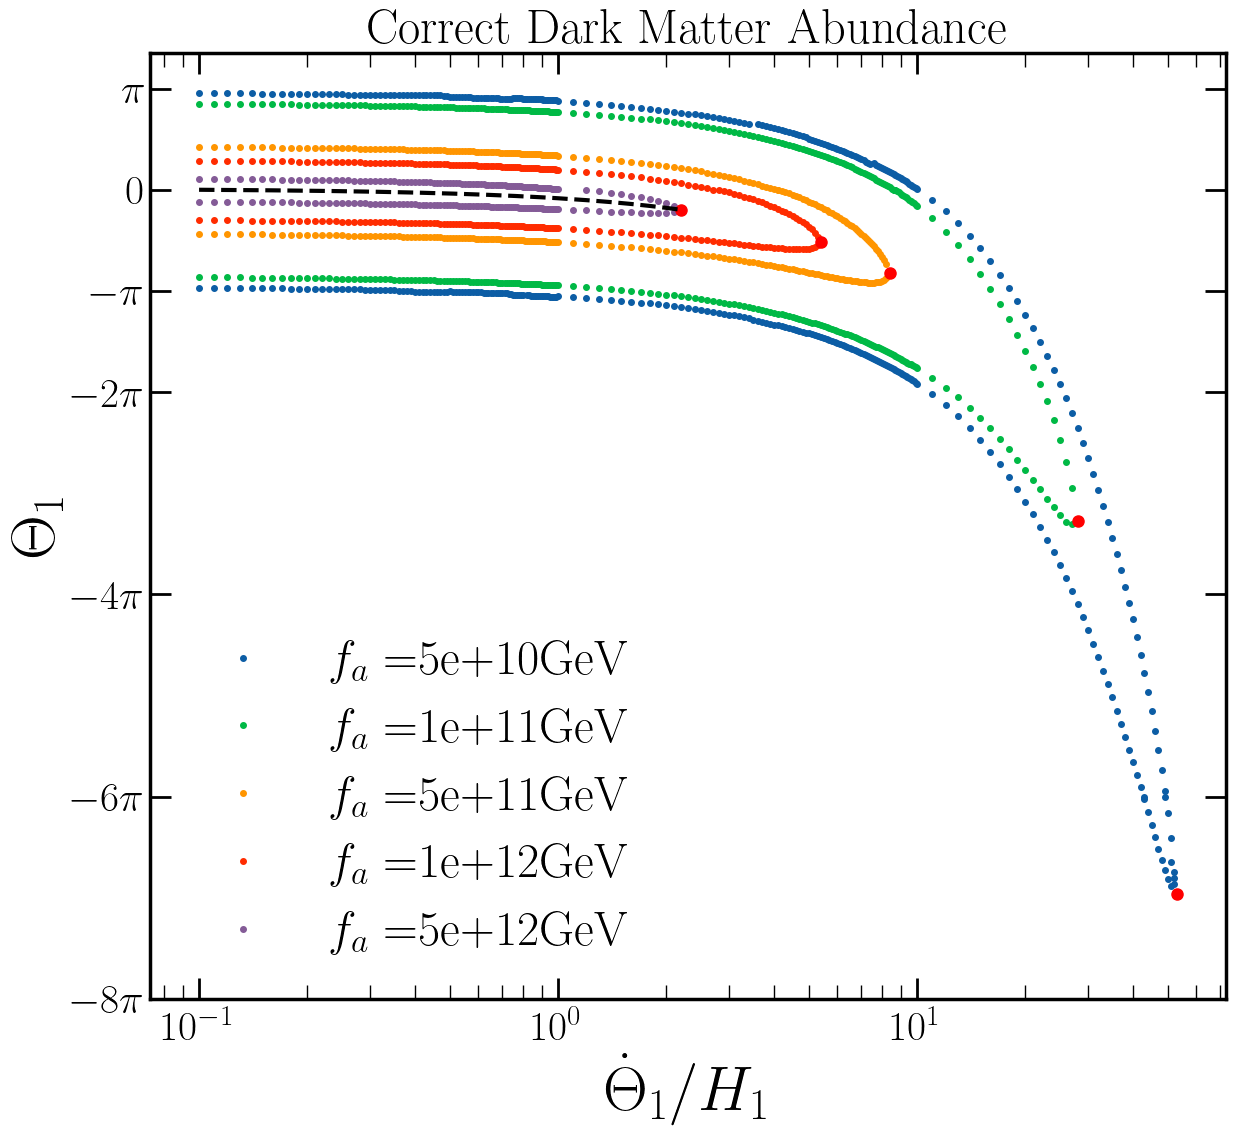

In [4]:
import numpy as np
import matplotlib.pyplot as plt

fit_theta1_vals = []
fit_vheta1_vals = []

tips, fAs = [], []

for k, v in param_pairs_dict.items():
    theta1_vals = np.asarray([t[0] for t in v])
    vheta1_vals = np.asarray([t[1] for t in v])
    
    fAs.append(k)
    if k > 10**11:
        # Sort by x for cleaner plotting
        sort_idx = np.argsort(vheta1_vals)
        theta1_vals = theta1_vals[sort_idx]
        vheta1_vals = vheta1_vals[sort_idx]

        # Find median theta to separate branches
        median_theta = 0.5*(theta1_vals.max() + theta1_vals.min())
        upper_mask = theta1_vals > median_theta

        # Plot lower branch
        plt.plot(vheta1_vals[~upper_mask], theta1_vals[~upper_mask], markersize=8, 
                 marker='.', linestyle='', label=fr'$f_a = ${k:.0e}GeV')

        # Plot shifted upper branch
        plt.plot(vheta1_vals[upper_mask], theta1_vals[upper_mask] - 2*np.pi, markersize=8, 
                 marker='.', linestyle='', color=plt.gca().lines[-1].get_color())

        # Store tip for fit
        fit_theta1_vals.append(theta1_vals[-1])
        fit_vheta1_vals.append(vheta1_vals[-1])

        # Plot tip as red dot
        plt.plot(vheta1_vals[-1], theta1_vals[-1]-2*np.pi, 'ro', markersize=8)
        
        tips.append((vheta1_vals[-1], theta1_vals[-1]-2*np.pi))

    elif k == 10**11:
        neg_shift_idx = np.unique(np.concatenate([
            np.arange(369, 388, 2),
            np.arange(388, 399, 1),
        ]))
        pos_shift_idx = np.unique(np.concatenate([
            np.arange(0, 333, 2),
            [335]
        ]))

        # Apply shifts
        theta1_vals[neg_shift_idx] -= 2*np.pi
        theta1_vals[pos_shift_idx] += 2*np.pi

        plt.plot(vheta1_vals, theta1_vals-2*np.pi, label=fr'$f_a = ${k:.0e}GeV', markersize=8, marker='.', linestyle='')

        # Plot tip
        plt.plot(vheta1_vals[-1], theta1_vals[-1]-2*np.pi, 'ro', markersize=8)
        
        tips.append((vheta1_vals[-1], theta1_vals[-1]-2*np.pi))

    elif k == 5*10**10:
        neg_shift_idx = np.unique(np.array([
            361, 363, 365, 367, 369, 371, 373, 375, 377, 379, 381, 383, 385, 387, 389, 
            390, 391, 392, 393, 394, 
            396, 398, 400, 402, 404, 406, 408, 410, 412, 414
        ]))
        dneg_shift_idx = np.unique(np.array([
            395, 397, 399, 401, 403, 405, 407, 409, 411, 413, 415, 416, 417, 418, 419, 420,
            421, 422, 423, 424, 425,
            427, 429, 431, 433, 435, 437
        ]))
        ddneg_shift_idx = np.unique(np.array([
            426, 428, 430, 432, 434, 436, 438,
            439, 440, 441, 442, 443, 444, 445, 446, 447, 448
        ]))
        pos_shift_idx = np.unique(np.concatenate([
            np.arange(0, 143, 2),
            np.arange(143, 145, 2),
            np.arange(144, 230, 2),
            np.arange(231, 308, 2),
            np.arange(310, 360, 2),
        ]))

        theta1_vals[neg_shift_idx] -= 2*np.pi
        theta1_vals[dneg_shift_idx] -= 4*np.pi
        theta1_vals[ddneg_shift_idx] -= 6*np.pi
        theta1_vals[pos_shift_idx] += 2*np.pi

        plt.plot(vheta1_vals, theta1_vals-2*np.pi, label=fr'$f_a = ${k:.0e}GeV', markersize=8, marker='.', linestyle='')

        # Plot tip
        plt.plot(vheta1_vals[-1], theta1_vals[-1]-2*np.pi, 'ro', markersize=8)
        
        tips.append((vheta1_vals[-1], theta1_vals[-1]-2*np.pi))

# Polynomial fit using the tip points
coeffs = np.polyfit(fit_vheta1_vals, fit_theta1_vals, deg=2)
p = np.poly1d(coeffs)

# Plot the polynomial
plt.plot(vheta1_vals, p(vheta1_vals)-2*np.pi, 'k--')

plt.xlabel(r'$\dot{\Theta}_1/H_1$')
plt.ylabel(r'$\Theta_1$')
plt.xscale('log')
plt.yticks([-8*np.pi, -6*np.pi, -4*np.pi, -2*np.pi, -np.pi, 0, np.pi],
           [r'$-8\pi$', r'$-6\pi$', r'$-4\pi$', r'$-2\pi$', r'$-\pi$', r'$0$', r'$\pi$'])
plt.title('Correct Dark Matter Abundance', fontweight='bold')
plt.tight_layout()
plt.legend(loc='lower left')
plt.show()
plt.close()


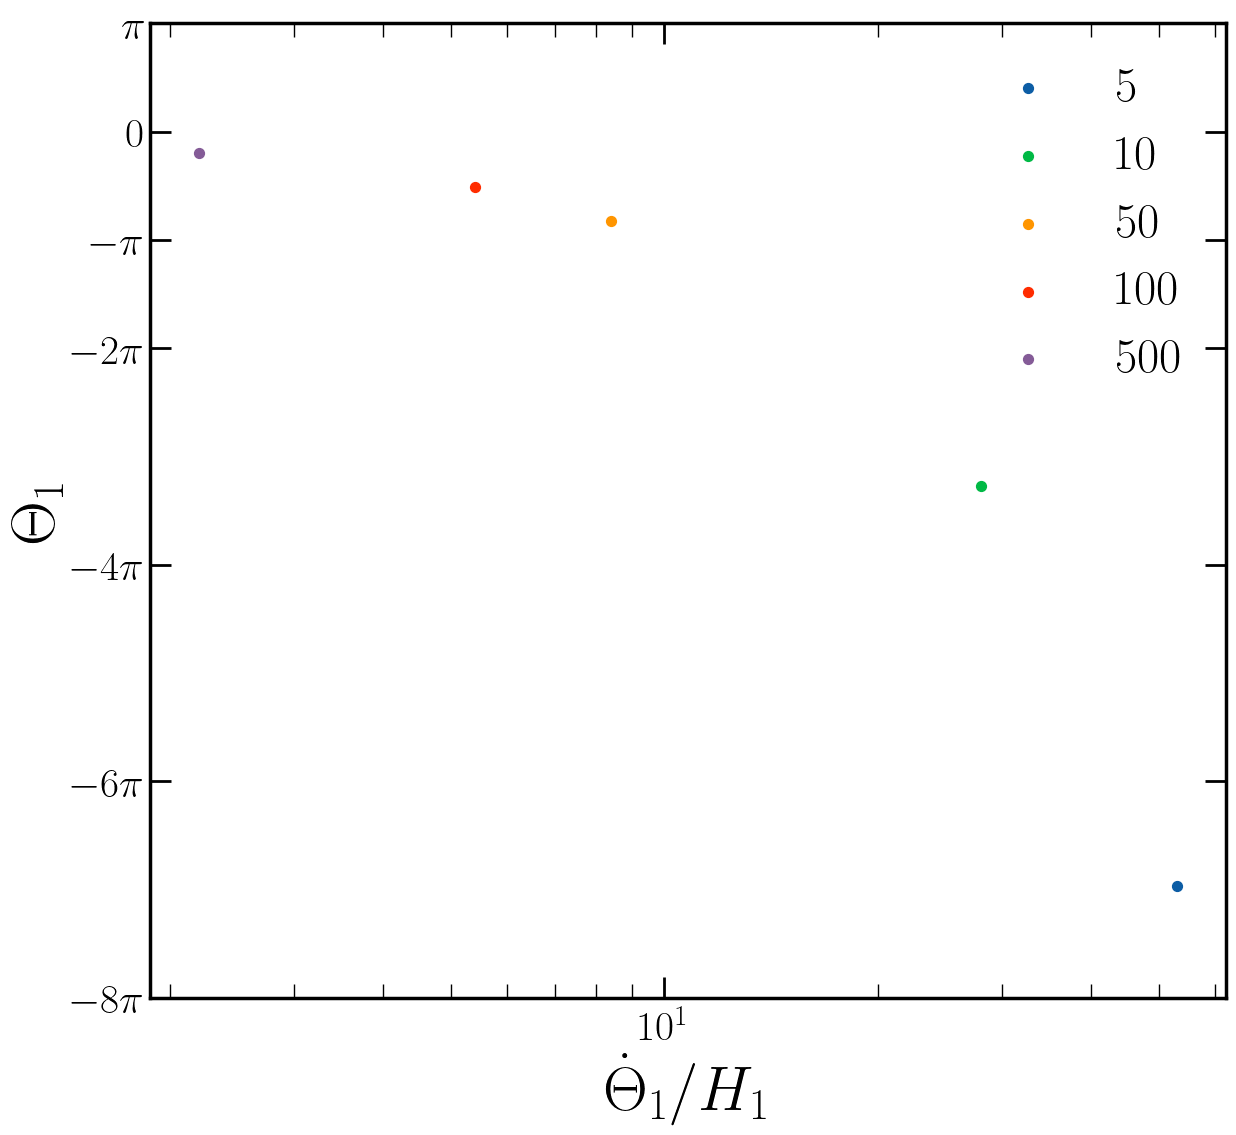

In [5]:
plt.figure()

for id, fA in enumerate(fAs):
    plt.scatter(tips[id][0], tips[id][1], s=50, label = '%d'%(fA/1e10))
    
    
plt.xlabel(r'$\dot{\Theta}_1/H_1$')
plt.ylabel(r'$\Theta_1$')
plt.xscale('log')
plt.yticks([-8*np.pi, -6*np.pi, -4*np.pi, -2*np.pi, -np.pi, 0, np.pi],
           [r'$-8\pi$', r'$-6\pi$', r'$-4\pi$', r'$-2\pi$', r'$-\pi$', r'$0$', r'$\pi$'])
plt.tight_layout()

plt.legend()

In [6]:
tips = np.array(tips)        # shape (N, 2)
fAs = np.array(fAs)          # shape (N,)

vtheta_tips = tips[:, 0]
theta_tips = tips[:, 1]

# Use log scale for fA
log_fAs = np.log10(fAs)

In [7]:
fA_kirthi, vheta_kirthi, theta_kirthi = fAs, vtheta_tips, theta_tips

In [8]:
fA_kirthi, vheta_kirthi, theta_kirthi+4*np.pi

(array([5.e+10, 1.e+11, 5.e+11, 1.e+12, 5.e+12]),
 array([53. , 28. ,  8.4,  5.4,  2.2]),
 array([-9.31821716,  2.28866489,  9.96778023, 10.95205614, 11.9468595 ]))

In [9]:
coeffs_vtheta = np.polyfit(log_fAs, vtheta_tips, deg=1)  
p_vtheta = np.poly1d(coeffs_vtheta)

In [10]:
coeffs_theta = np.polyfit(log_fAs, theta_tips, deg=1)
p_theta = np.poly1d(coeffs_theta)

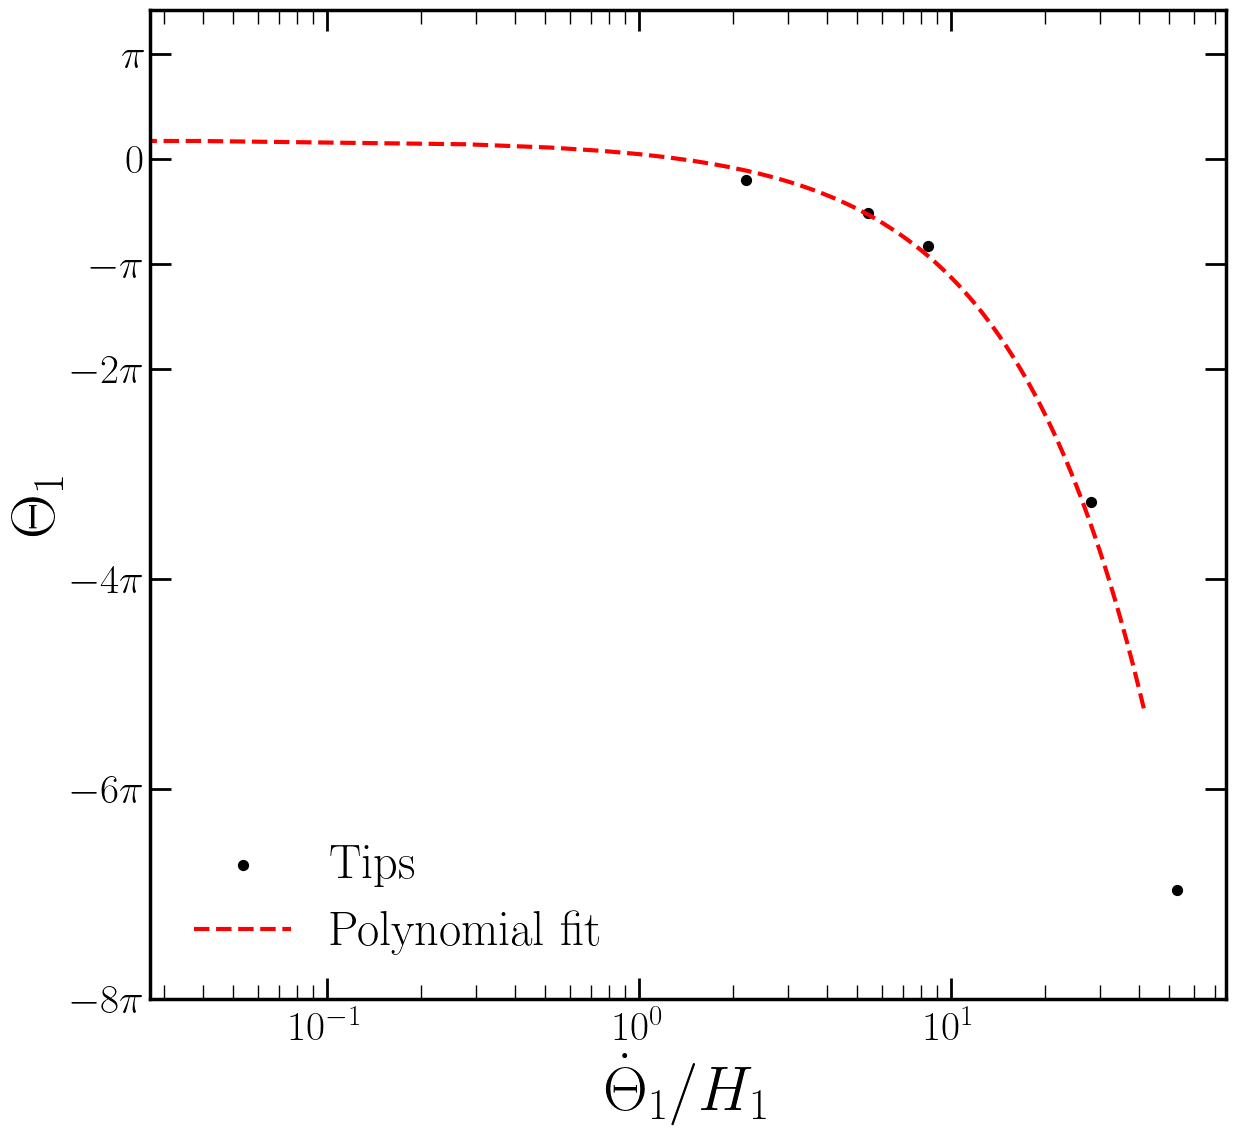

In [11]:
fA_fit = np.logspace(np.log10(fAs.min()), np.log10(fAs.max()), 200)
vtheta_fit = p_vtheta(np.log10(fA_fit))
theta_fit = p_theta(np.log10(fA_fit))

plt.figure()
plt.scatter(vtheta_tips, theta_tips, s=50, color='k', label='Tips')
plt.plot(vtheta_fit, theta_fit, 'r--', label='Polynomial fit')

plt.xlabel(r'$\dot{\Theta}_1/H_1$')
plt.ylabel(r'$\Theta_1$')
plt.xscale('log')
plt.yticks([-8*np.pi, -6*np.pi, -4*np.pi, -2*np.pi, -np.pi, 0, np.pi],
           [r'$-8\pi$', r'$-6\pi$', r'$-4\pi$', r'$-2\pi$', r'$-\pi$', r'$0$', r'$\pi$'])
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
from scipy.optimize import curve_fit

def log_linear(x, a, b):
    return a * np.log10(x) + b #* np.log10(x)**2 
popt_theta, _ = curve_fit(log_linear, fAs, theta_tips)
popt_vtheta, _ = curve_fit(log_linear, fAs, vtheta_tips)

In [13]:
fA_min = 1e9
fA_max = 5e12

fA_fit = np.logspace(np.log10(fA_min), np.log10(fA_max), 200)


theta_fit = log_linear(fA_fit, *popt_theta)
vtheta_fit = log_linear(fA_fit, *popt_vtheta)

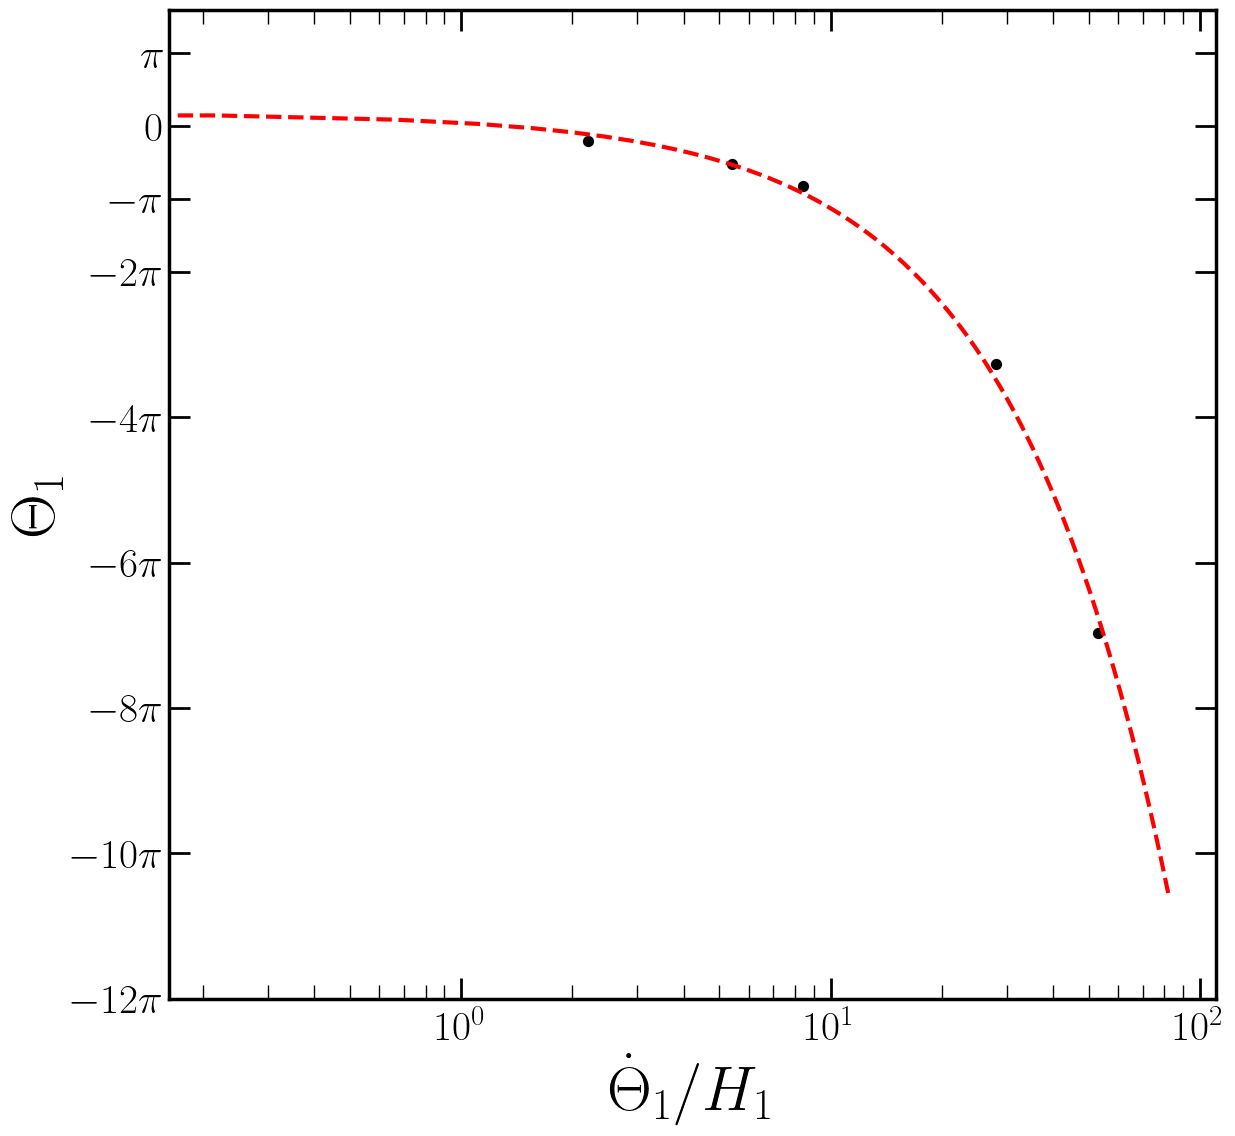

In [14]:
plt.figure()
plt.scatter(vtheta_tips, theta_tips, s=50, color='k', label='Tips')
plt.plot(vtheta_fit, theta_fit, 'r--', label='Polynomial fit')

plt.xlabel(r'$\dot{\Theta}_1/H_1$')
plt.ylabel(r'$\Theta_1$')

plt.xscale('log')
#plt.yscale('log')

plt.yticks([-12*np.pi, -10*np.pi, -8*np.pi, -6*np.pi, -4*np.pi, -2*np.pi, -np.pi, 0, np.pi],
           [r'$-12\pi$',r'$-10\pi$',r'$-8\pi$', r'$-6\pi$', r'$-4\pi$', r'$-2\pi$', r'$-\pi$', r'$0$', r'$\pi$'])

#plt.xlim(5e-2, 3e2)
#plt.ylim(-12*np.pi, np.pi)

#plt.legend()
plt.tight_layout()
plt.show()

41.44848203284539 -16.438137482892145
34.23730436105069 -13.481777706038969
17.49346832768606 -6.617322881568626
10.282290655891359 -3.660963104715435
-6.461545377473215 3.2034917197548936


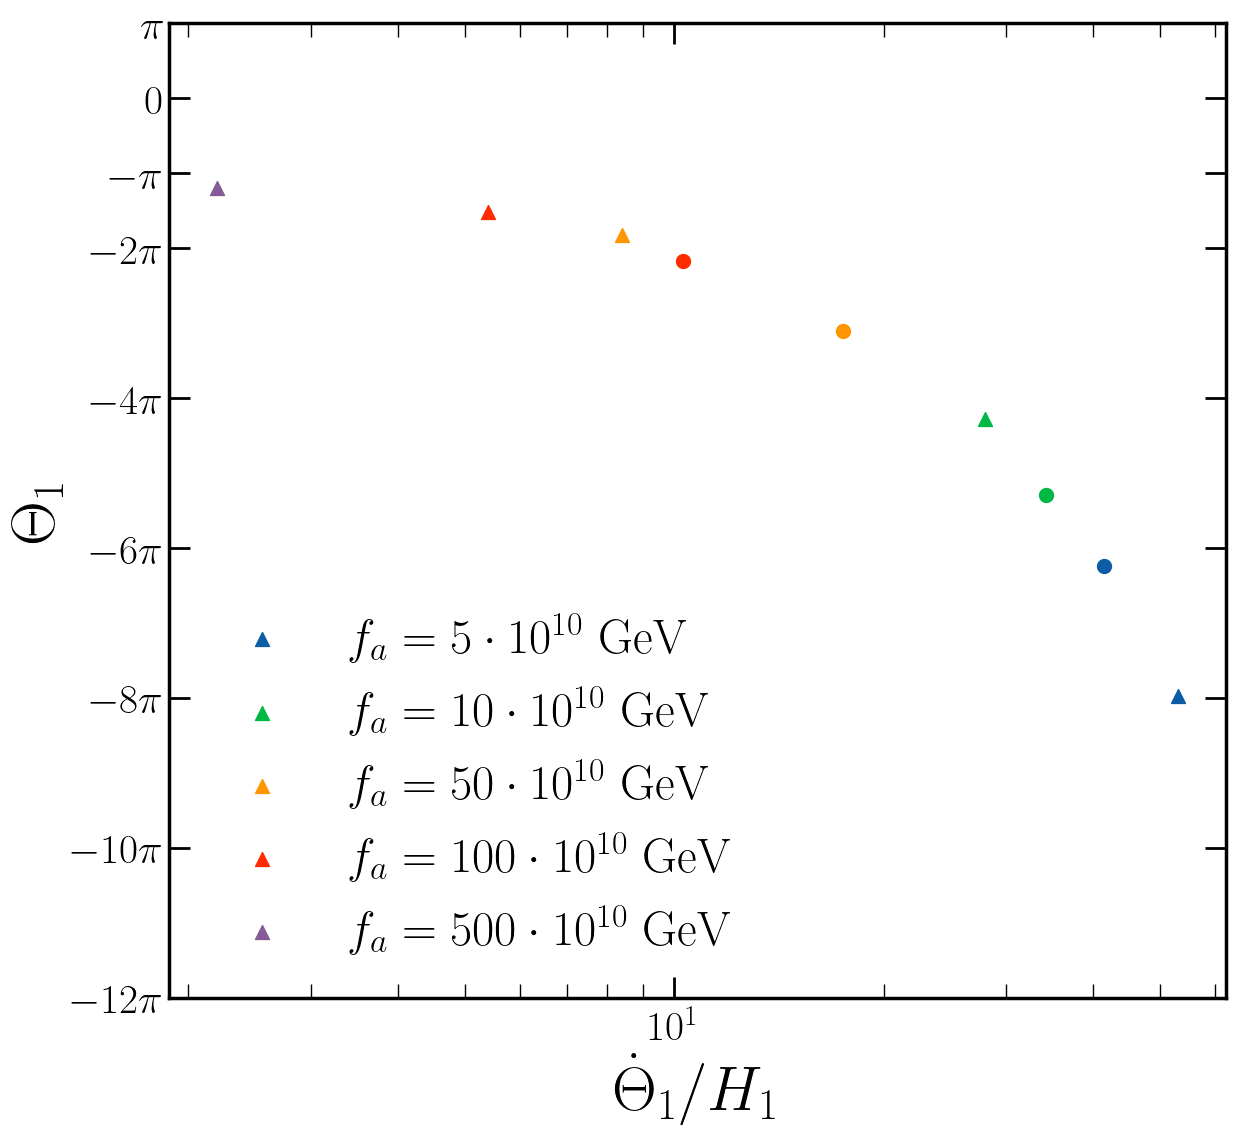

In [15]:
plt.figure()

for id in range(len(fAs)):
    target = fAs[id]#

    θ = log_linear(target, *popt_theta)
    v= log_linear(target, *popt_vtheta)
    print(v,θ)
    p = plt.scatter(v, θ-np.pi, s=100)
    plt.scatter(vtheta_tips[id], theta_tips[id]-np.pi, s=100, marker = '^', color = p.get_facecolors()[0],label=r'$f_a = %d \cdot 10^{10}$ GeV'%(fAs[id]//1e10))
plt.xlabel(r'$\dot{\Theta}_1/H_1$')
plt.ylabel(r'$\Theta_1$')
plt.xscale('log')
plt.yticks([-12*np.pi, -10*np.pi, -8*np.pi, -6*np.pi, -4*np.pi, -2*np.pi, -np.pi, 0, np.pi],
           [r'$-12\pi$',r'$-10\pi$',r'$-8\pi$', r'$-6\pi$', r'$-4\pi$', r'$-2\pi$', r'$-\pi$', r'$0$', r'$\pi$'])

#plt.xlim(1e-1, 1e2)
#plt.ylim(-9*np.pi, np.pi)

plt.legend()
plt.tight_layout()
plt.show()

## Experimental area

In [16]:
fAs = np.asarray(fAs)
tips = np.asarray(tips)
v_tips = tips[:,0]
theta_tips = tips[:,1]

In [17]:
def v_rational(f, vmax, c, *args):
    f = np.asarray(f, dtype=float)
    return vmax / (1.0 + (f / 5e9)**c)

# good initial guesses and bounds:
vmax0 = 3e3#max(v_tips) * 1.1              # a bit above max observed
#f0_0 = 1e10 #np.median(fAs)
c0 = 1

p0_v = [vmax0, c0]
bounds_v = ([0.0, .5], [1e4, 1.5])


weights = np.ones_like(fAs)
weights[-2:] = 1.0
sigma = 1 / weights

popt_v, pcov_v = curve_fit(v_rational, fAs, v_tips, p0=[vmax0, c0], bounds=bounds_v, sigma=sigma, maxfev=20000)

vmax_fit, c_fit = popt_v
print("v fit params: vmax, f0, c =", popt_v)

# compute fitted v values
f_dense = np.logspace(np.log10(1e9), np.log10(7e12), 500)
v_fit_dense = v_rational(f_dense, *popt_v)

v fit params: vmax, f0, c = [457.13506571   0.88927538]


In [18]:
# -------------------------
# Updated v(f) function with tail term
# -------------------------
def v_rational_tail(f, vmax, c, d, e, *args):
    """
    vmax: theoretical max velocity
    c   : exponent controlling steep rise at small fA
    d,e : exponent and coefficient controlling large fA tail
    """
    f = np.asarray(f, dtype=float)
    f0 = 5e9  # fixed characteristic force
    return vmax / (1 + (f/f0)**c + d*(f/f0)**e)

# -------------------------
# Initial guesses and bounds
# -------------------------
vmax0 = 3e3
c0 = 1.0
d0 = 0.01
e0 = 1.0

p0_v = [vmax0, c0, d0, e0]
bounds_v = ([0.0, 0.5, 0, 0], [1e4, 1.5, 1.0, 5.0])

# -------------------------
# Weighted residuals (favor last two fA points)
# -------------------------
weights = np.ones_like(fAs)
weights[4] = 10.0
weights[3] = 10.0
weights[2] = 10.0
weights[1] = 10.0
weights[0] = 10.0
sigma = 1 / weights  # smaller sigma → higher weight

# -------------------------
# Fit v(f)
# -------------------------
popt_v, pcov_v = curve_fit(v_rational_tail, fAs, v_tips, p0=p0_v,
                           bounds=bounds_v, sigma=sigma, maxfev=20000)

vmax_fit, c_fit, d_fit, e_fit = popt_v
print("Weighted v fit params: vmax, c, d, e =", popt_v)

# -------------------------
# Compute dense v(f) curve
# -------------------------
f_dense = np.logspace(np.log10(1e9), np.log10(7e12), 500)
v_fit_dense = v_rational_tail(f_dense, *popt_v)

v_fit_test =  v_rational_tail(fAs, *popt_v)

Weighted v fit params: vmax, c, d, e = [812.74596921   0.86151397   1.           0.86152551]


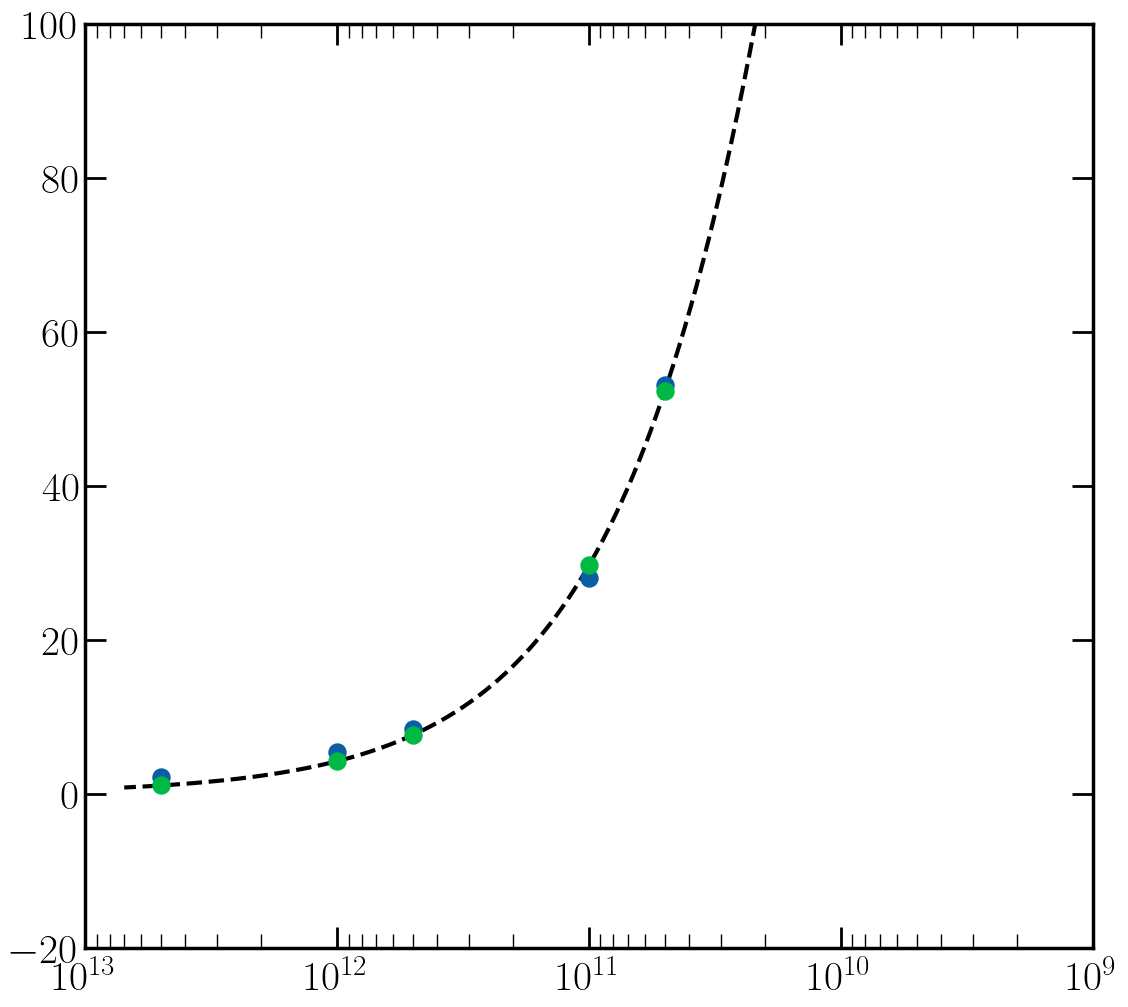

In [19]:
plt.figure()

plt.scatter(fAs, v_tips,s=150)
plt.plot(f_dense, v_fit_dense, 'k--', zorder = -1)

plt.scatter(fAs, v_fit_test,s=150)

plt.xlim(1e13,1e9)
plt.ylim(-20, 100)

plt.xscale('log')

In [20]:
def v_rational_flex(f, vmax, a, b, c):
    f0 = 1e9
    return vmax * (1 + a*(f/f0)**b) / (1 + (f/f0)**c)

# Initial guesses
vmax0 = 3e3
a0 = 0.1
b0 = 1.0
c0 = 1.0

p0 = [vmax0, a0, b0, c0]

# Bounds
bounds = ([0, -1, 0, 0.01], [1e4, 1, 5, 10])

popt, _ = curve_fit(v_rational_flex, fAs, v_tips, p0=p0, bounds=bounds, maxfev=20000)
vmax_fit, a_fit, b_fit, c_fit = popt
print("Fitted params:", popt)

# Evaluate
f_dense = np.logspace(np.log10(1e9), np.log10(7e12), 500)
v_fit_dense = v_rational_flex(f_dense, *popt)

Fitted params: [5.62120051e+03 3.08610274e-02 8.17762793e-01 1.33483803e+00]


In [21]:
def v_rational_tail(f, vmax, c, d, e):
    f0 = 1e9
    return vmax / (1 + (f/f0)**c + d * (f/f0)**e)

# Initial guesses
vmax0 = 3e3
c0 = 1.0
d0 = 0.1
e0 = 1.0

p0 = [vmax0, c0, d0, e0]

# Bounds
bounds = ([0, 0.01, 0, 0], [1e4, 10, 1, 5])

from scipy.optimize import curve_fit
popt, _ = curve_fit(v_rational_tail, fAs, v_tips, p0=p0, bounds=bounds, maxfev=20000)
vmax_fit, c_fit, d_fit, e_fit = popt
print("Fitted params:", popt)

# Evaluate dense curve
f_dense = np.logspace(np.log10(1e9), np.log10(7e12), 500)
v_fit_dense = v_rational_tail(f_dense, *popt)

Fitted params: [2.83126666e+03 8.38129899e-01 9.99936754e-01 8.38096267e-01]


In [22]:
#vmax_fit = .5e3

# -------------------------
# Step 2: fit Theta(v) with divergence at vmax
# Theta(v) = -A * (1 - v/vmax)^(-p) + C
# We can fix vmax to the fitted value to make fit stable.
# -------------------------
def theta_divergent(v, A, p, C):
    # penalize numeric blowup if v equals vmax_fit: use small eps to avoid divide-by-zero during fitting
    eps = 0#1e-12
    z = 1.0 - v / (vmax_fit + eps)
    # Ensure z positive for data not exceeding vmax; if z <=0 we'll get large values (physically expected)
    return -A * (z ** (-p)) + C

# initial guesses
A0 = max(-theta_tips) if np.any(theta_tips < 0) else 1.0
p0 = 0.5
C0 = 0.0

p0_th = [A0, p0, C0]
bounds_th = ([1e-12, 0.01, -np.inf], [np.inf, 10.0, np.inf])

# Fit theta vs v using only points with v < vmax_fit (if any equal-to-vmax may cause issues)
mask_valid = v_tips < (vmax_fit * 0.999999)
if not np.any(mask_valid):
    # if all v are extremely close to vmax, relax mask slightly
    mask_valid = np.ones_like(v_tips, dtype=bool)

popt_th, pcov_th = curve_fit(theta_divergent, v_tips[mask_valid], theta_tips[mask_valid],
                             p0=p0_th, bounds=bounds_th, maxfev=20000)
A_fit, p_fit, C_fit = popt_th
print("theta fit params A, p, C =", popt_th)

# Evaluate theta on the v-dense grid (avoid exactly vmax to prevent numerical blow-up)
v_dense_safe = np.clip(v_fit_dense, None, vmax_fit * 0.999999)
theta_fit_dense = theta_divergent(v_dense_safe, *popt_th)

theta fit params A, p, C = [106.60338598  10.         107.08745811]


In [23]:
#fAs, v_tips, theta_tips

50.0 98.2804830476021 5.576488339117603
100.0 57.201144236271666 1.4792569650696947
500.0 15.093357134003345 0.9140361504468828
1000.0 8.37694849718429 3.5612129090810427
5000.0 2.1100072675359676 5.969527381936068
10.0 288.5204544813858 2.149388951387799
5.0 406.3729846041288 0.98820882669893
1.0 650.2304382558112 3.0841594834064523


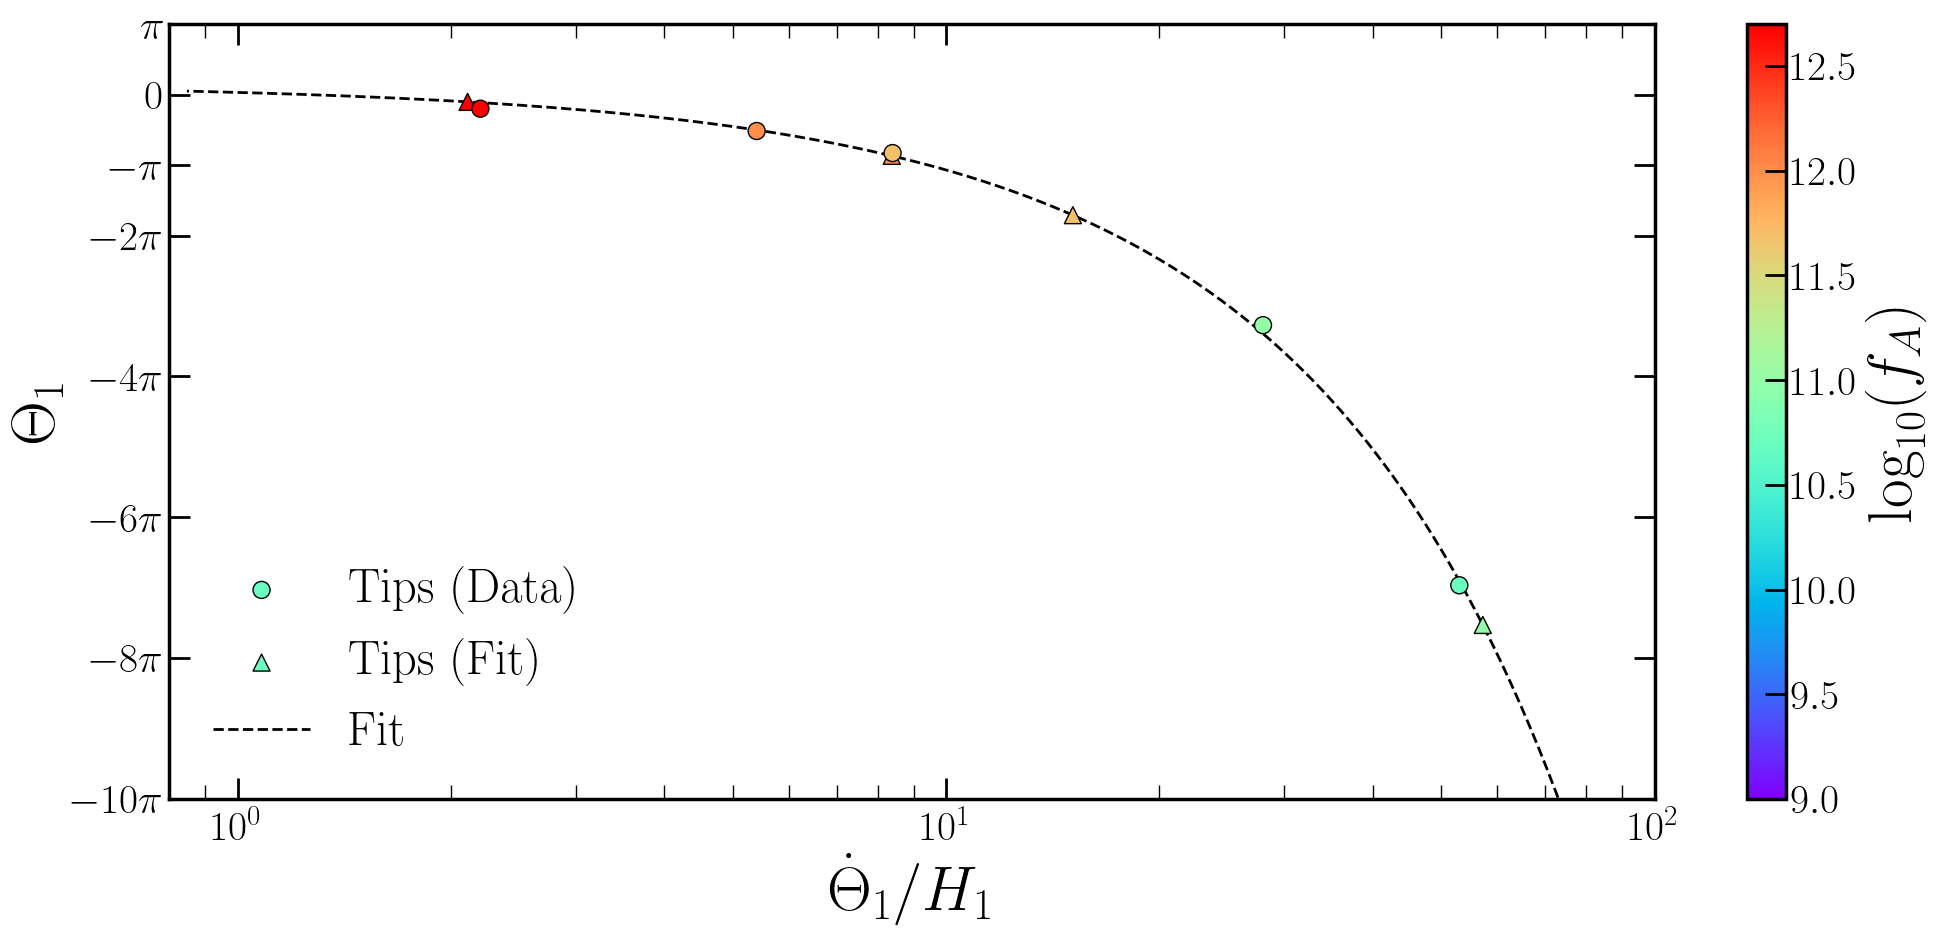

In [27]:
plt.figure(figsize=(21,10))
# scatter tip data
sc = plt.scatter(v_tips, theta_tips, s=150, c=np.log10(fAs), cmap='rainbow', edgecolor='k', label='Tips (Data)', zorder=10,vmin = 9, vmax=np.log10(5e12))


# mark extrapolated points at target fA
v_targets, theta_targets = [], []
f_targets = np.concatenate([fAs, np.array([1e10, 5e9, 1e9])])

for fA in f_targets:
    v_target = v_rational(fA, *popt_v)
    v_target_safe = min(v_target, vmax_fit*0.999999)
    theta_target = theta_divergent(v_target_safe, *popt_th)##
    print(fA//1e9, v_target_safe, theta_target%(2*np.pi))
    
    v_targets.append(v_target_safe)
    theta_targets.append(theta_target)
    
plt.scatter(v_targets, theta_targets,  c=np.log10(f_targets), cmap='rainbow', marker = '^', edgecolor='k', s=150, zorder=5, label = 'Tips (Fit)')#,vmin = 9, vmax=12)

# parametric curve (v(f), theta(f)) plotted as theta vs v
plt.plot(v_fit_dense, theta_fit_dense, 'k--', lw=2, label='Fit')

plt.colorbar(sc, label=r'$\log_{10}(f_A)$')

plt.xlabel(r'$\dot{\Theta}_1/H_1$')
plt.ylabel(r'$\Theta_1$')
plt.xscale('log')
plt.yticks([-12*np.pi, -10*np.pi, -8*np.pi, -6*np.pi, -4*np.pi, -2*np.pi, -np.pi, 0, np.pi],
           [r'$-12\pi$',r'$-10\pi$',r'$-8\pi$', r'$-6\pi$', r'$-4\pi$', r'$-2\pi$', r'$-\pi$', r'$0$', r'$\pi$'])

plt.xlim(8e-1, 1e2)
plt.ylim(-10*np.pi, 1*np.pi)

plt.legend(loc = 'lower left')

plt.tight_layout()
plt.show()

# More datapoints (Only scanning the tips)

In [3]:
os.getcwd()

'/Users/Mathieu/Desktop/Current Stuff/Kinetic Misalignment'

#### First run

In [4]:
data_path = 'data/tips_new.json'

with open(data_path, 'r') as f:
    data = json.load(f)

# Extract the tips dictionary (already keyed by fA strings)
tips = data['tips']

# Convert to fA-keyed dictionary with float keys
param_pairs_dict = {}
for fA_str, tip_data in tips.items():
    fA = float(fA_str)  # Convert string key "1.00e+11" to float 1e11
    param_pairs_dict[fA] = {
        'vheta': tip_data['vheta'],
        'theta_i': tip_data['theta_i'],
        'error': tip_data.get('error', 0)
    }

In [5]:
# Extract arrays for plotting (sorted by fA)
sorted_items = sorted(param_pairs_dict.items(), key=lambda x: x[0])
fAs = np.array([fA for fA, data in sorted_items])
v_tips = np.array([data['vheta'] for fA, data in sorted_items])

print(fAs, v_tips)

def shift(theta, n):
    return theta - n*2*np.pi


n_shift = np.ones(len(fAs))#np.array([5,4,4,3,3,3,3,2,2,2,1,1,1,1,1,1,1]) #last six points

theta_tips = shift(np.array([data['theta_i'] for fA, data in sorted_items]), n_shift)

[1.27e+10 1.83e+10 2.64e+10 3.79e+10 5.00e+10 5.46e+10 7.85e+10 1.00e+11
 1.13e+11 1.62e+11 2.34e+11 3.36e+11 4.83e+11 5.00e+11 6.95e+11 1.00e+12
 5.00e+12] [228.33007812 153.40454102 103.76578613  71.32598633  54.05738281
  49.78217773  35.55101562  28.60662109  25.73839844  19.29953125
  14.40208984  11.08509766   8.66564453   8.41199219   6.83154297
   5.46035156   2.18566406]


#### low $f_A < 10^9$

In [6]:
# Load the results from the JSON file
with open('data/lowfA1.json', 'r') as f:
    data = json.load(f)

# Extract the results list 
results_list = data['results']

# Convert to the format needed for plotting
param_pairs_dict = {}
for result in results_list:
    if result['success']:  # Only include successful scans
        fA = float(result['fA'])
        param_pairs_dict[fA] = {
            'vheta': result['tip_vheta'],
            'theta_i': result['tip_theta'],
            'error': result['tip_error']
        }

# Extract arrays for plotting (sorted by fA)
sorted_items = sorted(param_pairs_dict.items(), key=lambda x: x[0])
fAs_lowfA1 = np.array([fA for fA, data in sorted_items])
v_tips_lowfA1 = np.array([data['vheta'] for fA, data in sorted_items])

n_shift = np.ones(len(fAs_lowfA1))#np.array([7,6,6])#np.array([7,6,6])  # Adjust as needed
theta_tips_lowfA1 = shift(np.array([data['theta_i'] for fA, data in sorted_items]), n_shift)

print(fAs_lowfA1)
print(v_tips_lowfA1)
print(theta_tips_lowfA1)

[4.32e+09 6.16e+09 8.86e+09]
[779.83964363 516.81478654 340.15883614]
[-1.83023716 -4.16363231 -1.95602666]


In [7]:
# Load the results from the JSON file
with open('data/lowfA2.json', 'r') as f:
    data = json.load(f)

# Extract the results list 
results_list = data['results']

# Convert to the format needed for plotting
param_pairs_dict = {}
for result in results_list:
    if result['success']:  # Only include successful scans
        fA = float(result['fA'])
        param_pairs_dict[fA] = {
            'vheta': result['tip_vheta'],
            'theta_i': result['tip_theta'],
            'error': result['tip_error']
        }

# Extract arrays for plotting (sorted by fA)
sorted_items = sorted(param_pairs_dict.items(), key=lambda x: x[0])
fAs_lowfA2 = np.array([fA for fA, data in sorted_items])
v_tips_lowfA2 = np.array([data['vheta'] for fA, data in sorted_items])

n_shift = np.ones(len(fAs_lowfA2))#np.array([7,6,6])#np.array([7,6,6])  # Adjust as needed
theta_tips_lowfA2 = shift(np.array([data['theta_i'] for fA, data in sorted_items]), n_shift)

print(fAs_lowfA2)
print(v_tips_lowfA2)
print(theta_tips_lowfA2)

[1.00e+09 1.46e+09 2.10e+09 3.01e+09]
[4303.48228204 2742.66490517 1785.15658839 1175.44940103]
[-0.37107901 -1.81765821 -1.40255288 -3.7422375 ]


#### Combine the data 

In [9]:
fAs_full = np.concatenate([fAs, fAs_lowfA1, fAs_lowfA2])
vheta_full = np.concatenate([v_tips, v_tips_lowfA1, v_tips_lowfA2])
theta_full = np.concatenate([theta_tips, theta_tips_lowfA1, theta_tips_lowfA2])

data = np.column_stack([fAs_full, vheta_full, theta_full])
#np.savetxt('tips_final.txt', data)

### Fit

In [32]:
def v_rational_tail(f, vmax, c, d, e):
    f0 = 1e10
    return vmax / (1 + (f/f0)**c + d * (f/f0)**e)

# Initial guesses
vmax0 = 3e3
c0 = 1.0
d0 = 0.1
e0 = 1.0

p0 = [vmax0, c0, d0, e0]

# Bounds
bounds = ([0, 0.01, 0, 0], [1e4, 10, 1, 5])


popt, _ = curve_fit(v_rational_tail, fAs, v_tips, p0=p0, bounds=bounds, maxfev=20000)
vmax_fit, c_fit, d_fit, e_fit = popt
print("Fitted params:", popt)

# Evaluate dense curve
f_dense = np.logspace(np.log10(5e9), np.log10(1e14), 500)
v_fit_dense = v_rational_tail(f_dense, *popt)

Fitted params: [811.86746582   1.19419999   0.99999974   1.19420418]


In [33]:
#vmax_fit = .5e3

# -------------------------
# Step 2: fit Theta(v) with divergence at vmax
# Theta(v) = -A * (1 - v/vmax)^(-p) + C
# We can fix vmax to the fitted value to make fit stable.
# -------------------------
def theta_divergent(v, A, p, C):
    # penalize numeric blowup if v equals vmax_fit: use small eps to avoid divide-by-zero during fitting
    eps = 0#1e-12
    z = 1.0 - v / (vmax_fit + eps)
    # Ensure z positive for data not exceeding vmax; if z <=0 we'll get large values (physically expected)
    return -A * (z ** (-p)) + C

# initial guesses
A0 = max(-theta_tips) if np.any(theta_tips < 0) else 1.0
p0 = 0.5
C0 = 0.0

p0_th = [A0, p0, C0]
bounds_th = ([1e-12, 0.01, -np.inf], [np.inf, 10.0, np.inf])

# Fit theta vs v using only points with v < vmax_fit (if any equal-to-vmax may cause issues)
mask_valid = v_tips < (vmax_fit * 0.999999)
if not np.any(mask_valid):
    # if all v are extremely close to vmax, relax mask slightly
    mask_valid = np.ones_like(vheta_full, dtype=bool)

popt_th, pcov_th = curve_fit(theta_divergent, v_tips[mask_valid], theta_tips[mask_valid],
                             p0=p0_th, bounds=bounds_th, maxfev=20000)
A_fit, p_fit, C_fit = popt_th
print("theta fit params A, p, C =", popt_th)

# Evaluate theta on the v-dense grid (avoid exactly vmax to prevent numerical blow-up)
v_dense_safe = np.clip(v_fit_dense, None, vmax_fit * 0.999999)
theta_fit_dense = theta_divergent(v_dense_safe, *popt_th)

theta fit params A, p, C = [1.12271184e+03 1.00000010e-02 1.12037565e+03]


In [34]:
x = fAs

# Linear interpolation (can switch to 'cubic')
interp_v = interp1d(x, v_tips, kind='linear', fill_value="extrapolate")
interp_theta = interp1d(x, theta_tips, kind='linear', fill_value="extrapolate")

# Prediction
fA_pred = 1e9
x_pred = np.log10(fA_pred)

v_pred = interp_v(x_pred)
theta_pred = interp_theta(x_pred)

### Plot

In [10]:
fA_range = np.logspace(13,9,100)

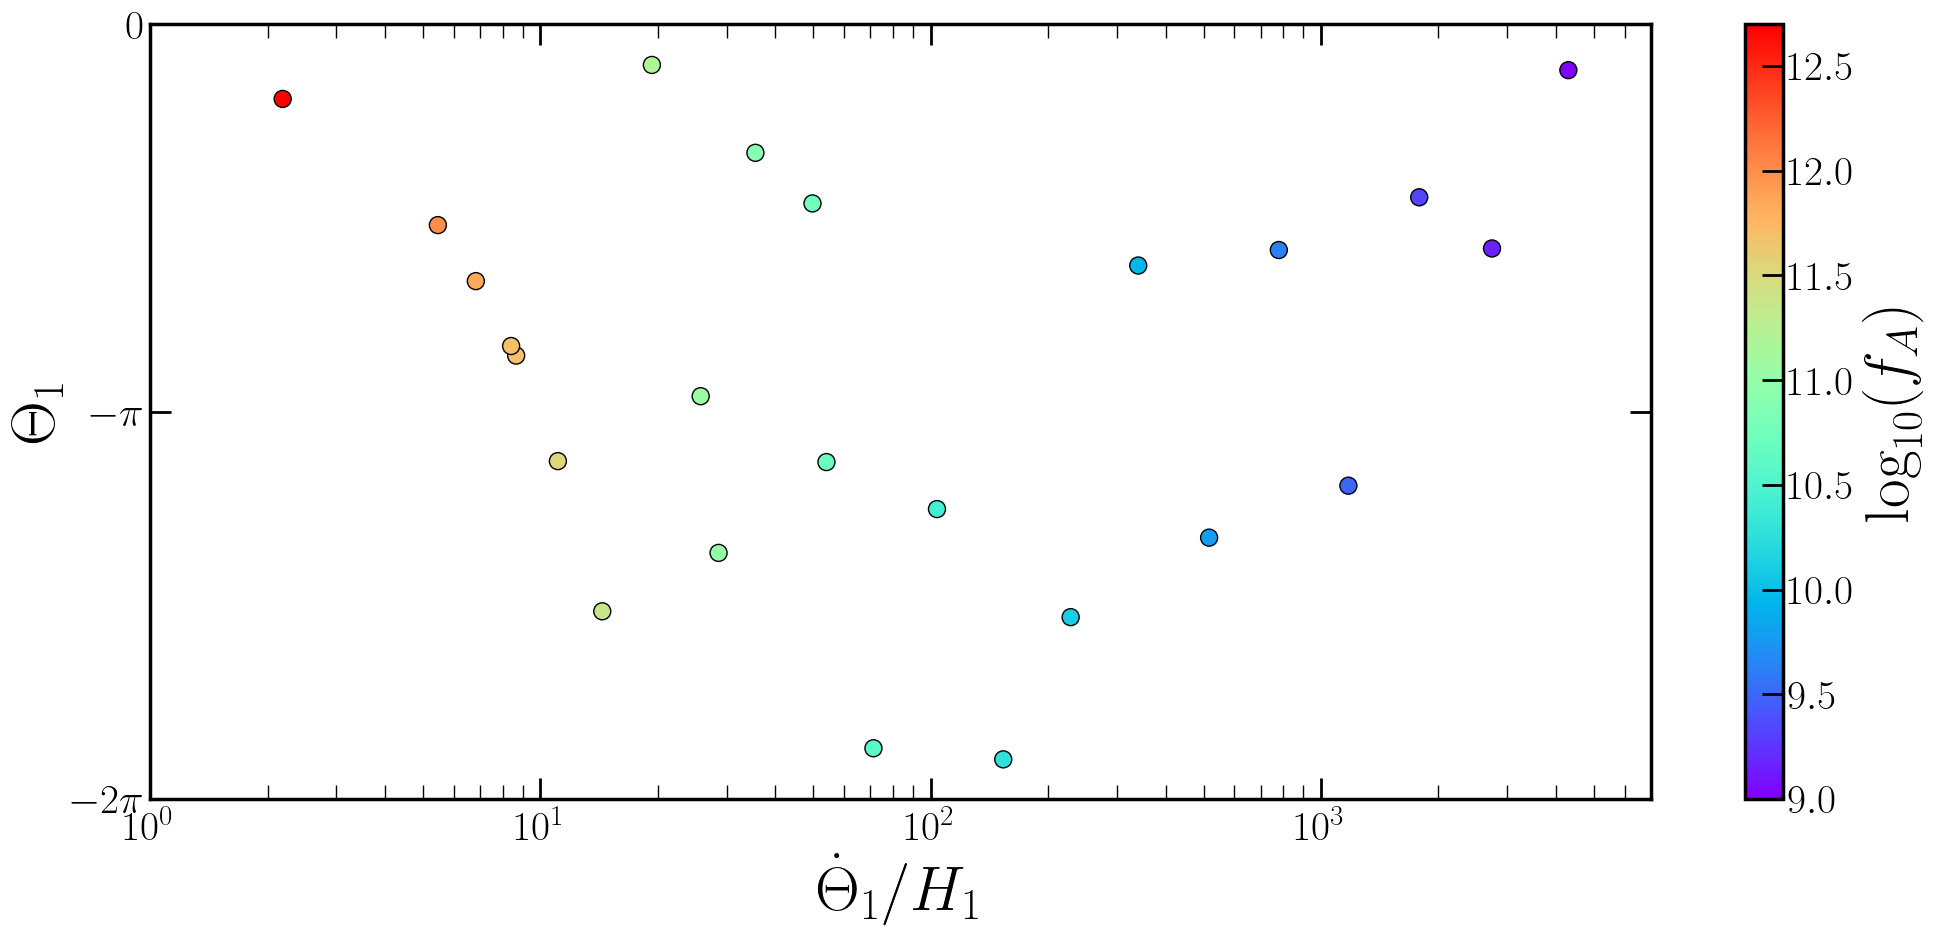

In [11]:
# Now your original plotting code works exactly as before:
plt.figure(figsize=(21,10))

# scatter tip data
sc = plt.scatter(vheta_full, theta_full, s=150, c=np.log10(fAs_full), cmap='rainbow', 
                edgecolor='k', label='Tips (Data)', zorder=10,
                vmin=9, vmax=np.log10(5e12))


#plt.scatter(vheta_kirthi, theta_kirthi, s=150, color='k', label='Tips (Data)', zorder=10)

# mark extrapolated points at target fA
#v_targets, theta_targets = [], []
#f_targets = np.concatenate([fAs, np.array([5e9, 1e9])])

#for fA in f_targets:
#    v_target = interp_v(fA)
#    theta_target = interp_theta(fA)
    #print(v_target)
   
#    v_targets.append(v_target)
#    theta_targets.append(theta_target)
    
#plt.scatter(v_targets, theta_targets, c=np.log10(f_targets), cmap='rainbow', 
#           marker='^', edgecolor='k', s=150, zorder=5, label='Tips (Fit)')

#plt.plot(interp_v(fA_range), interp_theta(fA_range), color = 'k', ls = 'dashed')

#plt.plot(np.logspace(-1,3,2), -np.pi*np.ones(2), color = 'k', ls = 'dashed')


plt.colorbar(sc, label=r'$\log_{10}(f_A)$')

plt.xlabel(r'$\dot{\Theta}_1/H_1$')
plt.ylabel(r'$\Theta_1$')
plt.xscale('log')
plt.yticks([-28*np.pi, -24*np.pi, -20*np.pi, -16*np.pi, -12*np.pi, -8*np.pi, -4*np.pi, -2*np.pi, -np.pi, 0],
           [r'$-28\pi$',r'$-24\pi$',r'$-20\pi$',r'$-16\pi$', r'$-12\pi$', r'$-8\pi$', r'$-4\pi$', r'$-2\pi$',r'$-\pi$', r'$0$'])

plt.xlim(1e0, 7e3)
plt.ylim(-2*np.pi, 0*np.pi)
#plt.ylim(-15*np.pi, np.pi)

#plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# $\theta$ Evolution

In [12]:
#Deal with the measurement files from the simulations
sys.path.insert(0, '/Users/Mathieu/Salsa/jaxionsdir/jaxions/scripts')
from pyaxions import jaxions as pa
from kin_mis_utils import evolution_kinetic_mis

os.environ["JAXIONS_DIR"] = "/Users/Mathieu/Salsa/jaxionsdir"

In [13]:
fAs_full, vheta_full, theta_full

(array([1.27e+10, 1.83e+10, 2.64e+10, 3.79e+10, 5.00e+10, 5.46e+10,
        7.85e+10, 1.00e+11, 1.13e+11, 1.62e+11, 2.34e+11, 3.36e+11,
        4.83e+11, 5.00e+11, 6.95e+11, 1.00e+12, 5.00e+12, 4.32e+09,
        6.16e+09, 8.86e+09, 1.00e+09, 1.46e+09, 2.10e+09, 3.01e+09]),
 array([2.28330078e+02, 1.53404541e+02, 1.03765786e+02, 7.13259863e+01,
        5.40573828e+01, 4.97821777e+01, 3.55510156e+01, 2.86066211e+01,
        2.57383984e+01, 1.92995313e+01, 1.44020898e+01, 1.10850977e+01,
        8.66564453e+00, 8.41199219e+00, 6.83154297e+00, 5.46035156e+00,
        2.18566406e+00, 7.79839644e+02, 5.16814787e+02, 3.40158836e+02,
        4.30348228e+03, 2.74266491e+03, 1.78515659e+03, 1.17544940e+03]),
 array([-4.80876431, -5.96231585, -3.93194741, -5.87242137, -3.55058815,
        -1.45225385, -1.04172296, -4.28730913, -3.01607866, -0.32884303,
        -4.76133705, -3.54286556, -2.68673945, -2.60907934, -2.08257017,
        -1.62805186, -0.6045223 , -1.83023716, -4.16363231, -1.95602666,


12700000000.0 : 18
18300000000.0 : 11
26400000000.0 : 7
37900000000.0 : 4
50000000000.0 : 3
54600000000.0 : 3
78500000000.0 : 2
100000000000.0 : 1
113000000000.0 : 1
162000000000.0 : 1
234000000000.0 : 0
336000000000.0 : 0
483000000000.0 : 0
500000000000.0 : 0
695000000000.0 : 0
1000000000000.0 : 0
5000000000000.0 : 0
4320000000.0 : 73
6160000000.0 : 46
8860000000.0 : 29
1000000000.0 : 463
1460000000.0 : 286
2100000000.0 : 180
3010000000.0 : 114


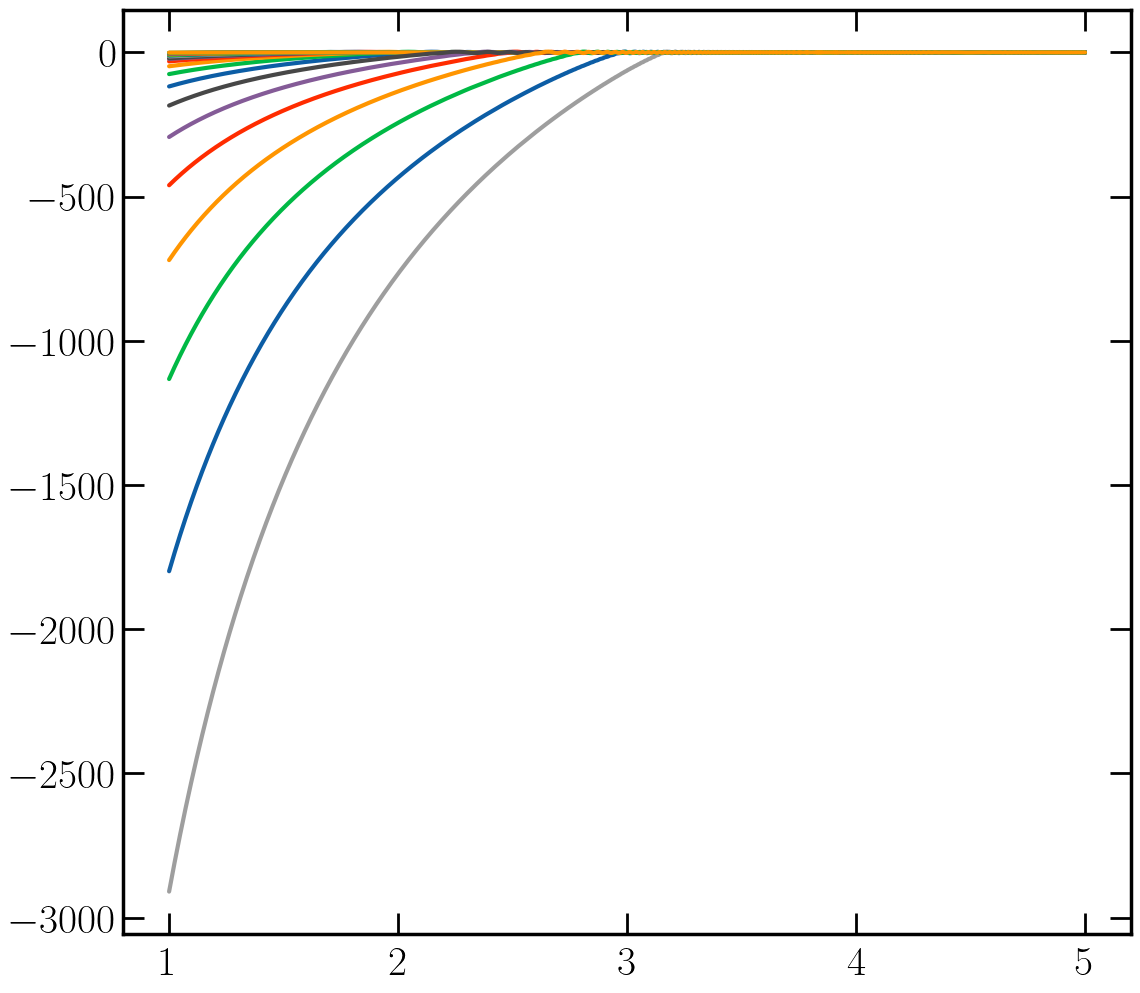

In [14]:
tautab = np.linspace(1, 5, 1000) # Normalized conformal time array, SHOULD START AT 1!

n_shifts = []
for id, fA in enumerate(fAs_full):
    tmp = evolution_kinetic_mis(fA, theta_full[id], vheta_full[id], tautab)
    
    plt.plot(tautab, tmp['thetatab']-np.mean(tmp['thetatab'][-10:]))
    
    n = int((np.mean(tmp['thetatab'][-10:])-tmp['thetatab'][0])/(2*np.pi))
    print(fA, ':',n)
    n_shifts.append(n)
#temp = evolution_kinetic_mis(1.00e+09, -0.37107901,4.30348228e+03, tautab)


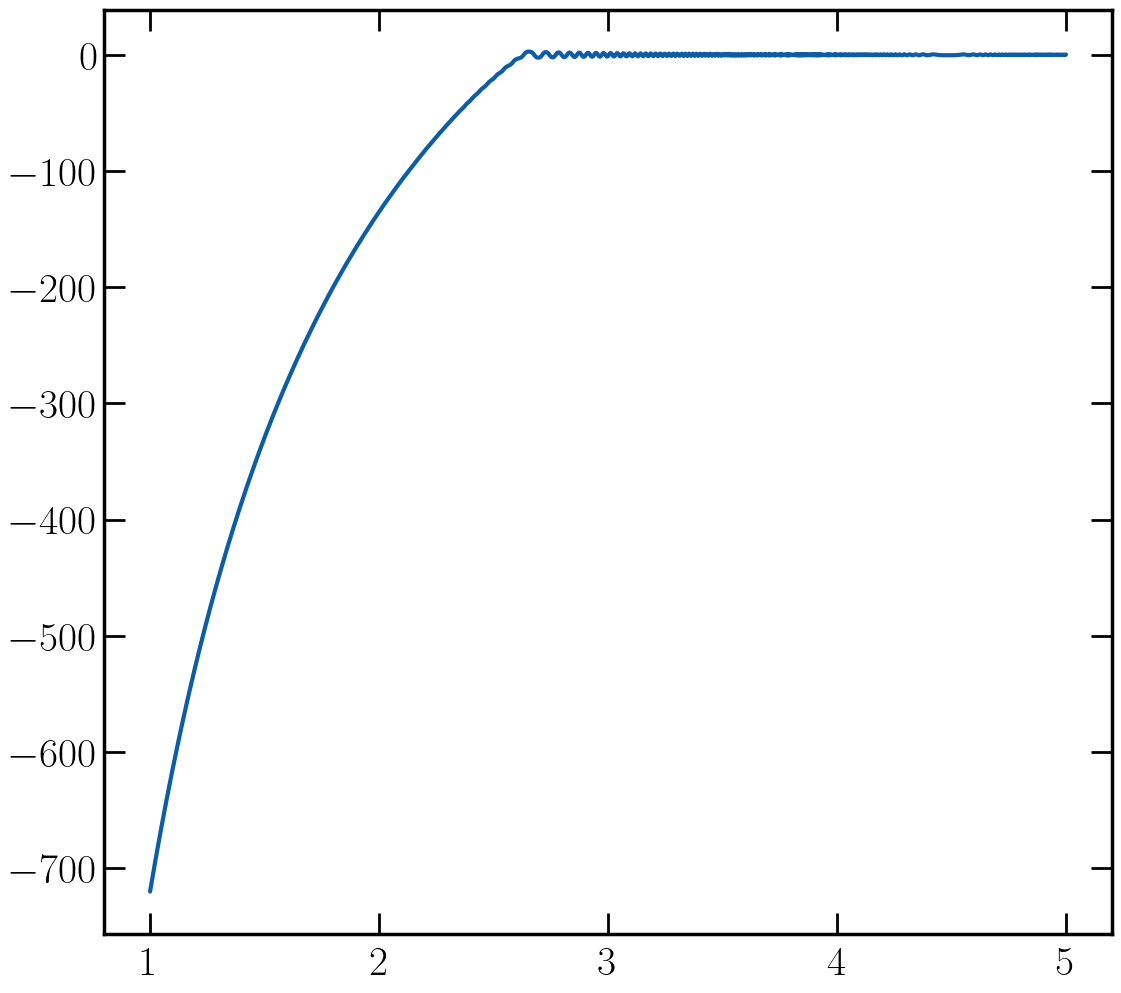

In [17]:
plt.plot(tautab, tmp['thetatab']-np.mean(tmp['thetatab'][-10:]))

In [18]:
theta_full_shifted = shift(theta_full, np.array(n_shifts))

data_shifted_theta = np.column_stack([fAs_full, vheta_full, theta_full_shifted])

#np.savetxt( 'tips_theta_shifted.txt', data_shifted_theta)

In [19]:
from scipy import stats
def fit_powerlaw(x, y):
    """
    Fit y = A * x^k by linear regression on log-log.
    Returns A, k, and r_value**2 (R^2 in log space).
    """
    x = np.asarray(x)
    y = np.asarray(y)
    if np.any(x <= 0) or np.any(y <= 0):
        raise ValueError("x and y must be > 0 for log-log fit")
    lx = np.log(x)
    ly = np.log(y)
    slope, intercept, r_value, p_value, std_err = stats.linregress(lx, ly)
    k = slope
    A = np.exp(intercept)
    r2 = r_value**2
    return A, k, r2, std_err  # std_err is slope std error

In [20]:
# Example:
A, k, r2, slope_err = fit_powerlaw(vheta_full, -theta_full_shifted)
print(f"A = {A:.3g}, k = {k:.3g}, R^2 = {r2:.4f}")


x_range = np.logspace(-1,4,100)

A = 0.24, k = 1.13, R^2 = 0.9998


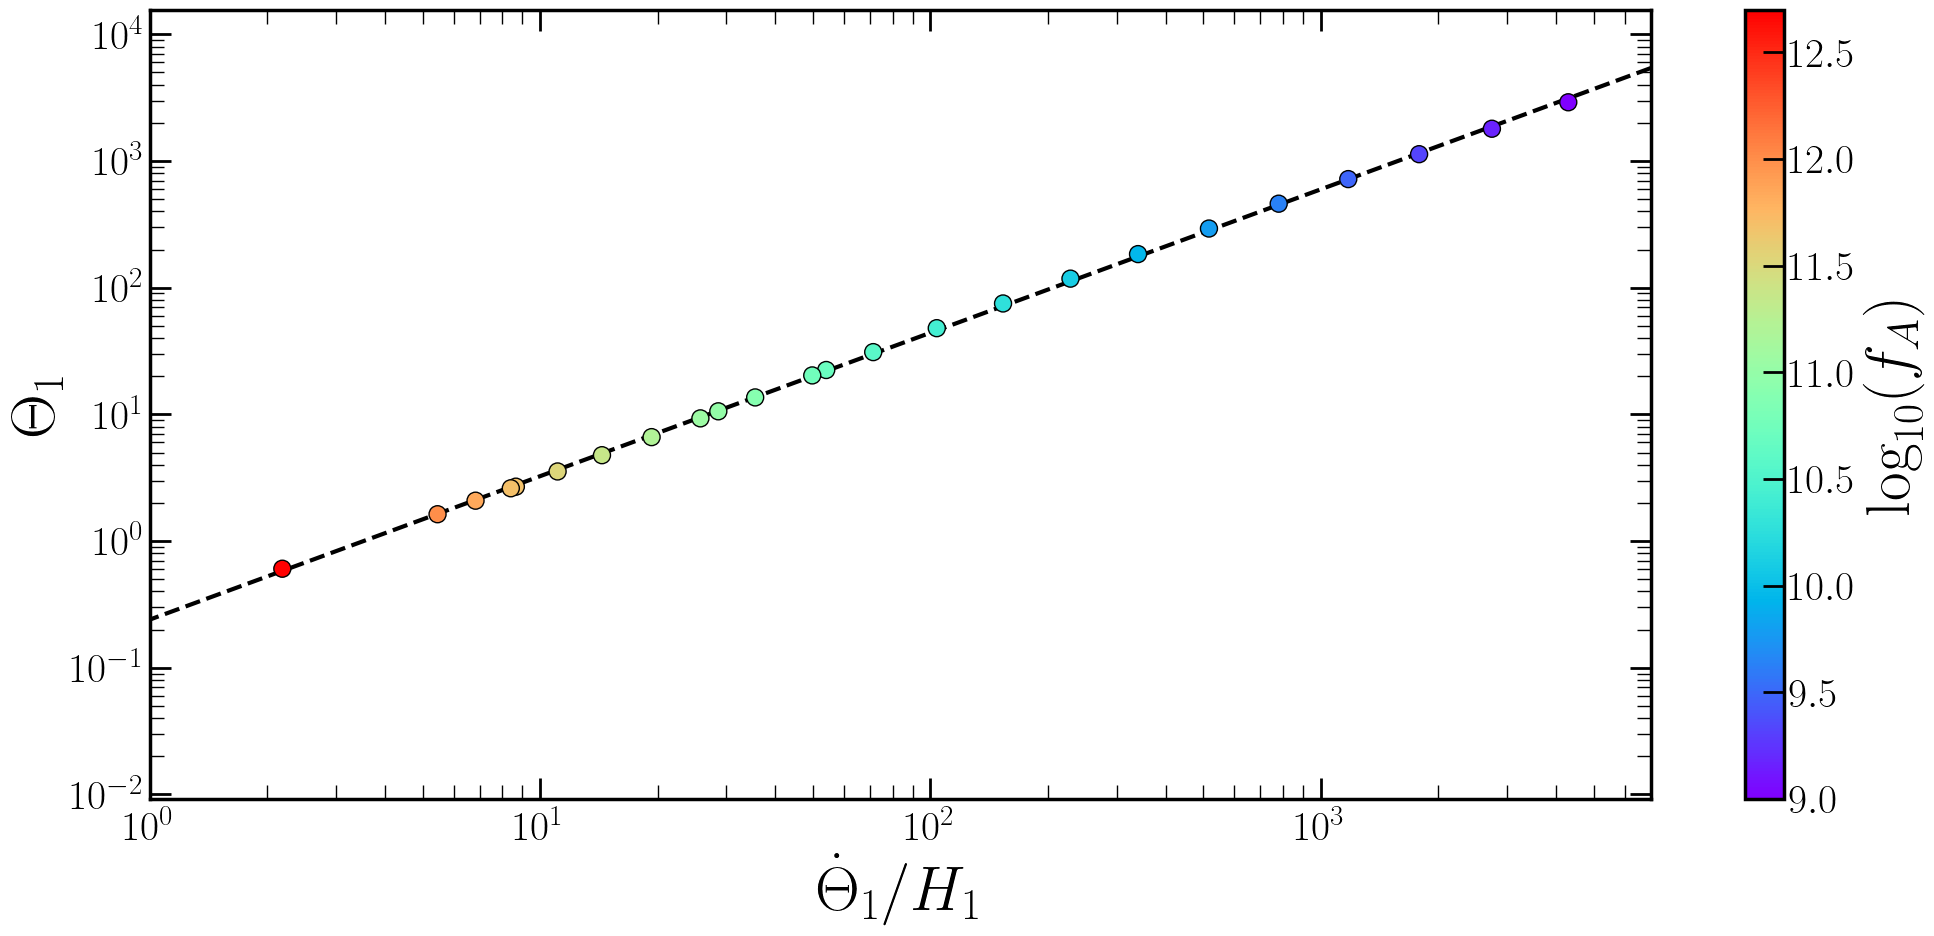

In [21]:
# Now your original plotting code works exactly as before:
plt.figure(figsize=(21,10))

# scatter tip data
sc = plt.scatter(vheta_full, -theta_full_shifted, s=150, c=np.log10(fAs_full), cmap='rainbow', 
                edgecolor='k', label='Tips (Data)', zorder=10,
                vmin=9, vmax=np.log10(5e12))


#plt.scatter(vheta_kirthi, theta_kirthi, s=150, color='k', label='Tips (Data)', zorder=10)

plt.plot(x_range, A*x_range**k, 'k--')

plt.colorbar(sc, label=r'$\log_{10}(f_A)$')

plt.xlabel(r'$\dot{\Theta}_1/H_1$')
plt.ylabel(r'$\Theta_1$')

plt.xscale('log')
plt.yscale('log')

#plt.yticks([-28*np.pi, -24*np.pi, -20*np.pi, -16*np.pi, -12*np.pi, -8*np.pi, -4*np.pi, -2*np.pi, -np.pi, 0],
#           [r'$-28\pi$',r'$-24\pi$',r'$-20\pi$',r'$-16\pi$', r'$-12\pi$', r'$-8\pi$', r'$-4\pi$', r'$-2\pi$',r'$-\pi$', r'$0$'])

plt.xlim(1e0, 7e3)
#plt.ylim(-2*np.pi, 0*np.pi)
#plt.ylim(-15*np.pi, np.pi)

#plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Physically motivated fits for the two params

In [66]:
# Velocity fit: pure power law ~ fA^(-1)
def theta_dot_max(fa, B, f0=1e9, q=-1): #plateau
    """
    Maximal velocity scaling with decay constant.

    Parameters
    ----------
    fa : array_like
        Axion decay constant [GeV].
    B : float
        Normalization (value at f0).
    f0 : float, optional
        Pivot scale for fa [GeV]. Default = 1e9 GeV.
    q : float, optional
        Power-law exponent. Physically q ≈ -1.
    """
    return B * (fa / f0)**q #+ plateau


# Angle fit: asymptotes to theta_min with mild power-law correction
def theta_max(fa, C, gamma=0.2, theta_min=1.35, f0=1e9):
    """
    Maximal angle scaling with decay constant.

    Parameters
    ----------
    fa : array_like
        Axion decay constant [GeV].
    C : float
        Normalization of the power-law correction.
    gamma : float, optional
        Power-law exponent. Physically gamma ≈ 0.2 for QCD axion.
    theta_min : float, optional
        Asymptotic minimum value. Physically ≈ 1.35.
    f0 : float, optional
        Pivot scale for fa [GeV]. Default = 1e9 GeV.
    """
    return theta_min + C * (fa / f0)**(-gamma)

In [52]:
vheta_full, -theta_full_shifted, s=150, c=np.log10(fAs_full),

SyntaxError: cannot assign to operator (3161744891.py, line 1)

In [ ]:
popt, pcov = curve_fit(theta_dot_max, fAs_full, vheta_full, p0 = [1, 1e9,-1])
popt

array([ 3.02274989e+01,  6.88592081e+10, -1.17097981e+00])

In [69]:
fA_range = np.logspace(8,13,100)

(0.1, 100000.0)

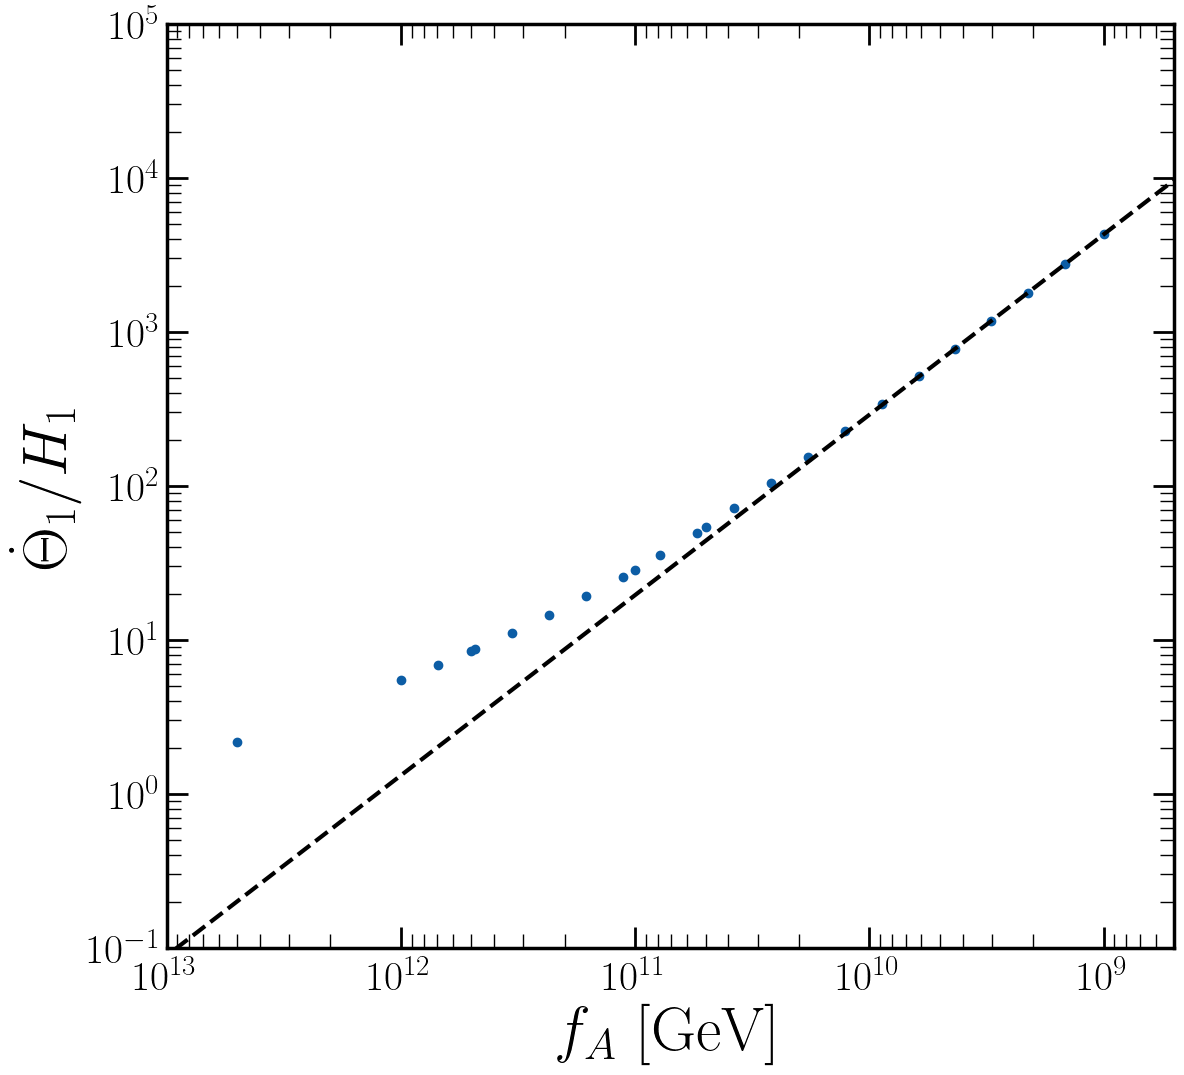

In [71]:
plt.figure()

plt.scatter(fAs_full, vheta_full)

plt.plot(fA_range, theta_dot_max(fA_range, *popt), 'k--')

#plt.plot(fA_range, theta_dot_max(fA_range, 0, 3e2, 1e10, -1), 'k--')


plt.xscale('log')
plt.yscale('log')


plt.xlabel(r'$f_A$ [GeV]')
plt.ylabel(r'$\dot{\Theta}_1/H_1$')

plt.xlim(1e13,5e8)


plt.ylim(1e-1,1e5)

In [79]:
popt, pcov = curve_fit(theta_max, fAs_full, -theta_full_shifted, p0 = [1, 0.2, 1.35, 1e9])
popt #C, gamma=0.2, theta_min=1.35, f0=1e9

/var/folders/gl/2f09_nld06g3yvhn8fd0fyb00000gn/T/ipykernel_30873/2453616940.py:38: RuntimeWarning: invalid value encountered in power
  return theta_min + C * (fa / f0)**(-gamma)


array([2.71460199e+03, 1.26855851e+00, 1.96582297e+00, 1.05522776e+09])

(10000000000000.0, 500000000.0)

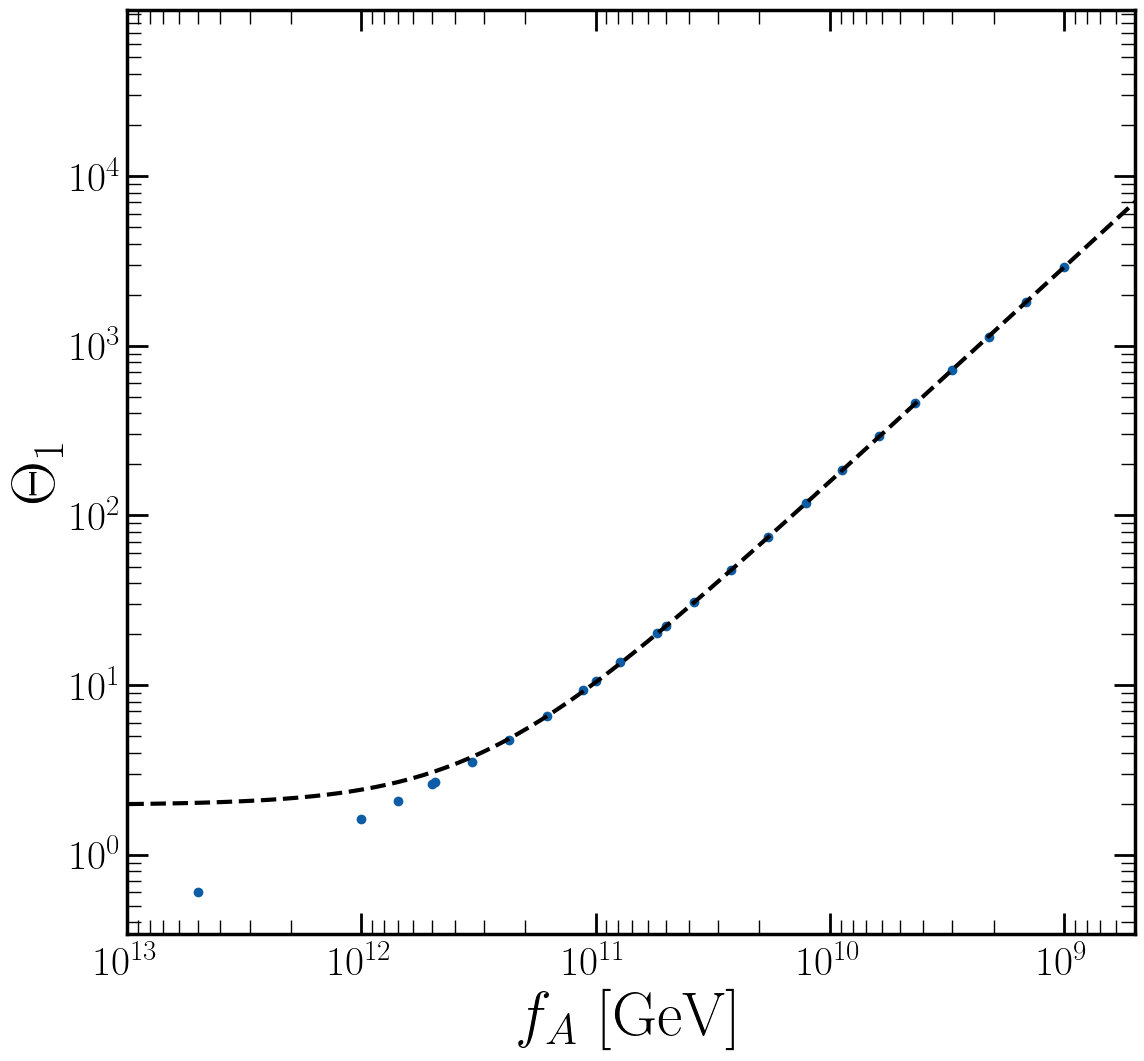

In [80]:
plt.figure()

plt.scatter(fAs_full, -theta_full_shifted)

plt.plot(fA_range, theta_max(fA_range, *popt), 'k--')

#plt.plot(fA_range, theta_dot_max(fA_range, 0, 3e2, 1e10, -1), 'k--')


plt.xscale('log')
plt.yscale('log')


plt.xlabel(r'$f_A$ [GeV]')
plt.ylabel(r'$\Theta_1$')

plt.xlim(1e13,5e8)


#plt.ylim(1e-1,1e5)